In [8]:
import warnings 
warnings.filterwarnings('ignore')

## K-Nearest-Neighbors

KNN falls in the supervised learning family of algorithms. Informally, this means that we are given a labelled dataset consiting of training observations (x,y) and would like to capture the relationship between x and y. More formally, our goal is to learn a function h:X→Y so that given an unseen observation x, h(x) can confidently predict the corresponding output y.

In this module we will explore the inner workings of KNN, choosing the optimal K values and using KNN from scikit-learn.

## Overview

1.Read the problem statement.

2.Get the dataset.

3.Explore the dataset.

4.Pre-processing of dataset.

5.Visualization

6.Transform the dataset for building machine learning model.

7.Split data into train, test set.

7.Build Model.

8.Apply the model.

9.Evaluate the model.

10.Finding Optimal K value

11.Repeat 7,8,9 steps.

## Problem statement

### Dataset

The data set we’ll be using is the Iris Flower Dataset which was first introduced in 1936 by the famous statistician Ronald Fisher and consists of 50 observations from each of three species of Iris (Iris setosa, Iris virginica and Iris versicolor). Four features were measured from each sample: the length and the width of the sepals and petals.

**Attributes of the dataset:** https://archive.ics.uci.edu/ml/datasets/Iris

**Train the KNN algorithm to be able to distinguish the species from one another given the measurements of the 4 features.**

In [9]:
import numpy as np
import pandas as pd
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from scipy.stats import zscore
from sklearn.preprocessing import Imputer
from sklearn.metrics import accuracy_score
from sklearn import metrics
# calculate accuracy measures and confusion matrix
from sklearn import metrics
from sklearn.metrics import accuracy_score, confusion_matrix, recall_score, precision_score, f1_score, auc, roc_curve
import seaborn as sns
# To enable plotting graphs in Jupyter notebook
%matplotlib inline 

## Question 1

Import the data set and print 10 random rows from the data set

In [10]:
df = pd.read_csv("iris.data",header = None)

In [11]:
df.columns= ["sepal_length","sepal_width","petal_length","petal_width","class"]

In [12]:
df.head(10)

,sepal_length,sepal_width,petal_length,petal_width,class
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
5,5.4,3.9,1.7,0.4,Iris-setosa
6,4.6,3.4,1.4,0.3,Iris-setosa
7,5.0,3.4,1.5,0.2,Iris-setosa
8,4.4,2.9,1.4,0.2,Iris-setosa
9,4.9,3.1,1.5,0.1,Iris-setosa


In [13]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
sepal_length,150.0,5.843333,0.828066,4.3,5.1,5.80,6.4,7.9
sepal_width,150.0,3.054000,0.433594,2.0,2.8,3.00,3.3,4.4
petal_length,150.0,3.758667,1.764420,1.0,1.6,4.35,5.1,6.9
petal_width,150.0,1.198667,0.763161,0.1,0.3,1.30,1.8,2.5


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
sepal_length    150 non-null float64
sepal_width     150 non-null float64
petal_length    150 non-null float64
petal_width     150 non-null float64
class           150 non-null object
dtypes: float64(4), object(1)
memory usage: 5.9+ KB


## Data Pre-processing

## Question 2 - Estimating missing values

*Its not good to remove the records having missing values all the time. We may end up loosing some data points. So, we will have to see how to replace those missing values with some estimated values (median) *

In [15]:
print((df[["sepal_length","sepal_width","petal_length","petal_width","class"]] == 0).sum())
# we can clearly see there is no 0 values in the columns of data set

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
class           0
dtype: int64


In [16]:
print(df.isnull().sum())

# we can clearly see there is no null/NaN values in the columnsof data set

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
class           0
dtype: int64


Hence we have no Missing values in the Data set 

## Question 3 - Dealing with categorical data

Change all the classes to numericals (0to2).

In [17]:
df.info()
#Hence we have no non numerical Class in the 0 to 3 column and 4th column is suppossed to be Categorical data


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
sepal_length    150 non-null float64
sepal_width     150 non-null float64
petal_length    150 non-null float64
petal_width     150 non-null float64
class           150 non-null object
dtypes: float64(4), object(1)
memory usage: 5.9+ KB


In [18]:
df.dtypes

sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
class            object
dtype: object

## Question 4

*Observe the association of each independent variable with target variable and drop variables from feature set having correlation in range -0.1 to 0.1 with target variable.*

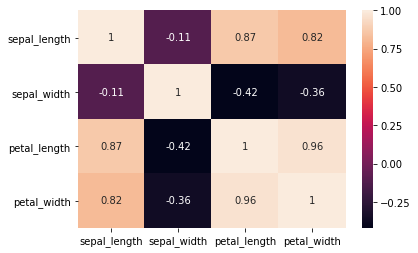

In [19]:
corr = df.corr()
sns.heatmap(corr, annot=True)

In [22]:
df1 = df.drop(labels= "sepal_width" , axis = 1)

## Question 5

*Observe the independent variables variance and drop such variables having no variance or almost zero variance(variance < 0.1). They will be having almost no influence on the classification.*

In [23]:
df1.var()

sepal_length    0.685694
petal_length    3.113179
petal_width     0.582414
dtype: float64

## Question 6

*Plot the scatter matrix for all the variables.*

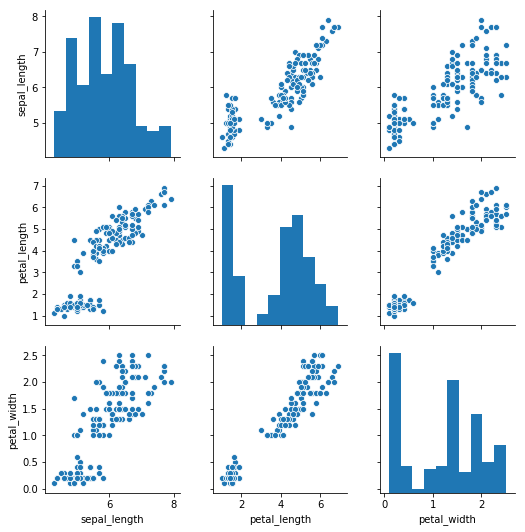

In [24]:
sns.pairplot(df1)

## Split the dataset into training and test sets

## Question 7

*Split the dataset into training and test sets with 80-20 ratio.*

In [25]:
X = df1.drop(labels= "class" , axis = 1)
y = df1[['class']]

In [26]:
test_size = 0.20 # taking 80:20 training and test set
seed = 7  # Random numbmer seeding for reapeatability of the code
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=seed)

## Question 8 - Model

*Build the model and train and test on training and test sets respectively using **scikit-learn**. Print the Accuracy of the model with different values of **k=3,5,9**.*

**Hint:** For accuracy you can check **accuracy_score()** in scikit-learn

In [27]:
#k =  n_neighbors= 3
NNH = KNeighborsClassifier(n_neighbors= 3)
NNH.fit(X_train, y_train)
predicted_labels = NNH.predict(X_test)
trainPred = NNH.predict(X_train)
testPred = NNH.predict(X_test)
trainaccuracy = accuracy_score(y_train, trainPred)
trainrecall = recall_score(y_train, trainPred ,average = 'micro')
trainprecision = precision_score(y_train, trainPred , average = 'micro')
trainf1 = f1_score(y_train, trainPred, average = 'micro')
print("k = 3")
print("trainaccuracy = ",trainaccuracy)
print("trainrecall = ",trainrecall)
print("trainprecision = ",trainprecision)
print("trainf1 = ",trainf1)
NNH.score(X_test, y_test)

k = 3
trainaccuracy =  0.9833333333333333
trainrecall =  0.9833333333333333
trainprecision =  0.9833333333333333
trainf1 =  0.9833333333333333


0.9

In [155]:
#k =  n_neighbors= 5
NNH = KNeighborsClassifier(n_neighbors= 5)
NNH.fit(X_train, y_train)
predicted_labels = NNH.predict(X_test)
trainPred = NNH.predict(X_train)
testPred = NNH.predict(X_test)
trainaccuracy = accuracy_score(y_train, trainPred)
trainrecall = recall_score(y_train, trainPred ,average = 'micro')
trainprecision = precision_score(y_train, trainPred , average = 'micro')
trainf1 = f1_score(y_train, trainPred, average = 'micro')
print("k = 5")
print("trainaccuracy = ",trainaccuracy)
print("trainrecall = ",trainrecall)
print("trainprecision = ",trainprecision)
print("trainf1 = ",trainf1)
NNH.score(X_test, y_test)

k = 5
trainaccuracy =  0.975
trainrecall =  0.975
trainprecision =  0.975
trainf1 =  0.975


/Applications/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:3: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  This is separate from the ipykernel package so we can avoid doing imports until


0.9

In [28]:
#k =  n_neighbors= 7
NNH = KNeighborsClassifier(n_neighbors= 7)
NNH.fit(X_train, y_train)
predicted_labels = NNH.predict(X_test)
trainPred = NNH.predict(X_train)
testPred = NNH.predict(X_test)
trainaccuracy = accuracy_score(y_train, trainPred)
#trainrecall = recall_score(y_train, trainPred ,average = 'micro')
#trainprecision = precision_score(y_train, trainPred , average = 'micro')
#trainf1 = f1_score(y_train, trainPred, average = 'micro')
print("k = 7")
print("trainaccuracy = ",trainaccuracy)
#print("trainrecall = ",trainrecall)
#print("trainprecision = ",trainprecision)
#print("trainf1 = ",trainf1)
MSE = 1 - trainaccuracy

k = 7
trainaccuracy =  0.9833333333333333


## Question 9 - Cross Validation

Run the KNN with no of neighbours to be 1,3,5..19 and *Find the **optimal number of neighbours** from the above list using the Mis classification error

Hint:

Misclassification error (MSE) = 1 - Test accuracy score. Calculated MSE for each model with neighbours = 1,3,5...19 and find the model with lowest MSE

In [41]:

k1 = 3
NNH = KNeighborsClassifier(n_neighbors= 3)
NNH.fit(X_train, y_train)
predicted_labels = NNH.predict(X_test)
trainPred = NNH.predict(X_train)
testPred = NNH.predict(X_test)
trainaccuracy = accuracy_score(y_train, trainPred)
#trainrecall = recall_score(y_train, trainPred ,average = 'micro')
#trainprecision = precision_score(y_train, trainPred , average = 'micro')
#trainf1 = f1_score(y_train, trainPred, average = 'micro')
print("k = 3")
print("trainaccuracy = ",trainaccuracy)
#print("trainrecall = ",trainrecall)
#print("trainprecision = ",trainprecision)
#print("trainf1 = ",trainf1)
MSE1 = 1 - trainaccuracy
print('MSE = ', MSE1)

k = 3
trainaccuracy =  0.9833333333333333
MSE =  0.01666666666666672


In [42]:
k2 =   5
NNH = KNeighborsClassifier(n_neighbors= 5)
NNH.fit(X_train, y_train)
predicted_labels = NNH.predict(X_test)
trainPred = NNH.predict(X_train)
testPred = NNH.predict(X_test)
trainaccuracy = accuracy_score(y_train, trainPred)
#trainrecall = recall_score(y_train, trainPred ,average = 'micro')
#trainprecision = precision_score(y_train, trainPred , average = 'micro')
#trainf1 = f1_score(y_train, trainPred, average = 'micro')
print("k = 5")
print("trainaccuracy = ",trainaccuracy)
#print("trainrecall = ",trainrecall)
#print("trainprecision = ",trainprecision)
#print("trainf1 = ",trainf1)
MSE2 = 1 - trainaccuracy
print('MSE = ', MSE2)

k = 5
trainaccuracy =  0.975
MSE =  0.025000000000000022


In [43]:
k3 =  7
NNH = KNeighborsClassifier(n_neighbors= 7)
NNH.fit(X_train, y_train)
predicted_labels = NNH.predict(X_test)
trainPred = NNH.predict(X_train)
testPred = NNH.predict(X_test)
trainaccuracy = accuracy_score(y_train, trainPred)
#trainrecall = recall_score(y_train, trainPred ,average = 'micro')
#trainprecision = precision_score(y_train, trainPred , average = 'micro')
#trainf1 = f1_score(y_train, trainPred, average = 'micro')
print("k = 7")
print("trainaccuracy = ",trainaccuracy)
#print("trainrecall = ",trainrecall)
#print("trainprecision = ",trainprecision)
#print("trainf1 = ",trainf1)
MSE3 = 1 - trainaccuracy
print('MSE = ', MSE3)

k = 7
trainaccuracy =  0.9833333333333333
MSE =  0.01666666666666672


In [44]:
k5 =  11
NNH = KNeighborsClassifier(n_neighbors= 11)
NNH.fit(X_train, y_train)
predicted_labels = NNH.predict(X_test)
trainPred = NNH.predict(X_train)
testPred = NNH.predict(X_test)
trainaccuracy = accuracy_score(y_train, trainPred)
#trainrecall = recall_score(y_train, trainPred ,average = 'micro')
#trainprecision = precision_score(y_train, trainPred , average = 'micro')
#trainf1 = f1_score(y_train, trainPred, average = 'micro')
print("k = 11")
print("trainaccuracy = ",trainaccuracy)
#print("trainrecall = ",trainrecall)
#print("trainprecision = ",trainprecision)
#print("trainf1 = ",trainf1)
MSE5 = 1 - trainaccuracy
print('MSE = ', MSE5)


k = 11
trainaccuracy =  0.9916666666666667
MSE =  0.008333333333333304


In [45]:
k6 = 13
NNH = KNeighborsClassifier(n_neighbors= 13)
NNH.fit(X_train, y_train)
predicted_labels = NNH.predict(X_test)
trainPred = NNH.predict(X_train)
testPred = NNH.predict(X_test)
trainaccuracy = accuracy_score(y_train, trainPred)
#trainrecall = recall_score(y_train, trainPred ,average = 'micro')
#trainprecision = precision_score(y_train, trainPred , average = 'micro')
#trainf1 = f1_score(y_train, trainPred, average = 'micro')
print("k = 13")
print("trainaccuracy = ",trainaccuracy)
#print("trainrecall = ",trainrecall)
#print("trainprecision = ",trainprecision)
#print("trainf1 = ",trainf1)
MSE6 = 1 - trainaccuracy
print('MSE = ', MSE6)

k = 13
trainaccuracy =  0.9833333333333333
MSE =  0.01666666666666672


In [32]:
k7 = 15
NNH = KNeighborsClassifier(n_neighbors= 15)
NNH.fit(X_train, y_train)
predicted_labels = NNH.predict(X_test)
trainPred = NNH.predict(X_train)
testPred = NNH.predict(X_test)
trainaccuracy = accuracy_score(y_train, trainPred)
#trainrecall = recall_score(y_train, trainPred ,average = 'micro')
#trainprecision = precision_score(y_train, trainPred , average = 'micro')
#trainf1 = f1_score(y_train, trainPred, average = 'micro')
print("k = 15")
print("trainaccuracy = ",trainaccuracy)
#print("trainrecall = ",trainrecall)
#print("trainprecision = ",trainprecision)
#print("trainf1 = ",trainf1)
MSE7 = 1 - trainaccuracy
print('MSE = ', MSE7)

k = 15
trainaccuracy =  0.9916666666666667
MSE =  0.008333333333333304


In [46]:
k8 =  17
NNH = KNeighborsClassifier(n_neighbors= 17)
NNH.fit(X_train, y_train)
predicted_labels = NNH.predict(X_test)
trainPred = NNH.predict(X_train)
testPred = NNH.predict(X_test)
trainaccuracy = accuracy_score(y_train, trainPred)
#trainrecall = recall_score(y_train, trainPred ,average = 'micro')
#trainprecision = precision_score(y_train, trainPred , average = 'micro')
#trainf1 = f1_score(y_train, trainPred, average = 'micro')
print("k = 17")
print("trainaccuracy = ",trainaccuracy)
#print("trainrecall = ",trainrecall)
#print("trainprecision = ",trainprecision)
#print("trainf1 = ",trainf1)
MSE8 = 1 - trainaccuracy
print('MSE = ', MSE8)

k = 17
trainaccuracy =  0.9916666666666667
MSE =  0.008333333333333304


In [47]:
k9 = 19
NNH = KNeighborsClassifier(n_neighbors= 19)
NNH.fit(X_train, y_train)
predicted_labels = NNH.predict(X_test)
trainPred = NNH.predict(X_train)
testPred = NNH.predict(X_test)
trainaccuracy = accuracy_score(y_train, trainPred)
#trainrecall = recall_score(y_train, trainPred ,average = 'micro')
#trainprecision = precision_score(y_train, trainPred , average = 'micro')
#trainf1 = f1_score(y_train, trainPred, average = 'micro')
print("k = 19")
print("trainaccuracy = ",trainaccuracy)
#print("trainrecall = ",trainrecall)
#print("trainprecision = ",trainprecision)
#print("trainf1 = ",trainf1)
MSE9 = 1 - trainaccuracy
print('MSE = ', MSE9)

k = 19
trainaccuracy =  0.9916666666666667
MSE =  0.008333333333333304


In [48]:
k4= 9
NNH = KNeighborsClassifier(n_neighbors= 9)
NNH.fit(X_train, y_train)
predicted_labels = NNH.predict(X_test)
trainPred = NNH.predict(X_train)
testPred = NNH.predict(X_test)
trainaccuracy = accuracy_score(y_train, trainPred)
#trainrecall = recall_score(y_train, trainPred ,average = 'micro')
#trainprecision = precision_score(y_train, trainPred , average = 'micro')
#trainf1 = f1_score(y_train, trainPred, average = 'micro')
print("k = 9")
print("trainaccuracy = ",trainaccuracy)
#print("trainrecall = ",trainrecall)
#print("trainprecision = ",trainprecision)
#print("trainf1 = ",trainf1)
MSE4 = 1 - trainaccuracy
print('MSE = ', MSE4)
print('k = 9 neighbours is optimal ')

k = 9
trainaccuracy =  0.9916666666666667
MSE =  0.008333333333333304
k = 9 neighbours is optimal 


## Question 10

*Plot misclassification error vs k (with k value on X-axis) using matplotlib.*

In [49]:
K = [k1,k2,k3,k4,k5,k6,k7,k8,k9]

In [50]:
MSE = [MSE1,MSE2,MSE3,MSE4,MSE5,MSE6,MSE7,MSE8,MSE9]

In [51]:
K

[3, 5, 7, 9, 11, 13, 15, 17, 19]

In [52]:
MSE

[0.01666666666666672,
 0.025000000000000022,
 0.01666666666666672,
 0.008333333333333304,
 0.008333333333333304,
 0.01666666666666672,
 0.008333333333333304,
 0.008333333333333304,
 0.008333333333333304]

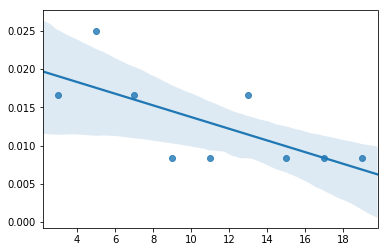

In [53]:
sns.regplot(x = K, y = MSE)

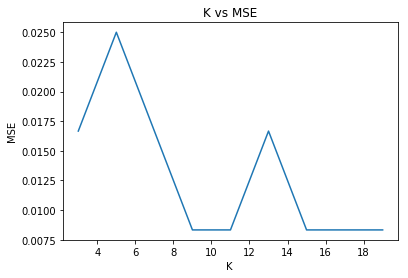

In [54]:
import matplotlib.pyplot as plt 
plt.plot(K, MSE) 
  
# naming the x axis 
plt.xlabel('K ') 
# naming the y axis 
plt.ylabel('MSE') 
  
# giving a title to my graph 
plt.title('K vs MSE') 
  
# function to show the plot 
plt.show() 

# Naive Bayes with Iris Data

In [55]:
#Load all required library
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
%matplotlib inline
from sklearn import datasets
from sklearn.decomposition import PCA
from sklearn.naive_bayes import GaussianNB, BernoulliNB, MultinomialNB

### Slice  Iris data set for Independent variables and dependent variables
#### Please note 'Species' is my dependent variables, name it y and independent set data as X

In [56]:
print(y)

              class
0       Iris-setosa
1       Iris-setosa
2       Iris-setosa
3       Iris-setosa
4       Iris-setosa
5       Iris-setosa
6       Iris-setosa
7       Iris-setosa
8       Iris-setosa
9       Iris-setosa
10      Iris-setosa
11      Iris-setosa
12      Iris-setosa
13      Iris-setosa
14      Iris-setosa
15      Iris-setosa
16      Iris-setosa
17      Iris-setosa
18      Iris-setosa
19      Iris-setosa
20      Iris-setosa
21      Iris-setosa
22      Iris-setosa
23      Iris-setosa
24      Iris-setosa
25      Iris-setosa
26      Iris-setosa
27      Iris-setosa
28      Iris-setosa
29      Iris-setosa
..              ...
120  Iris-virginica
121  Iris-virginica
122  Iris-virginica
123  Iris-virginica
124  Iris-virginica
125  Iris-virginica
126  Iris-virginica
127  Iris-virginica
128  Iris-virginica
129  Iris-virginica
130  Iris-virginica
131  Iris-virginica
132  Iris-virginica
133  Iris-virginica
134  Iris-virginica
135  Iris-virginica
136  Iris-virginica
137  Iris-virginica


In [57]:
#Check the dataset

print(X)

     sepal_length  petal_length  petal_width
0             5.1           1.4          0.2
1             4.9           1.4          0.2
2             4.7           1.3          0.2
3             4.6           1.5          0.2
4             5.0           1.4          0.2
5             5.4           1.7          0.4
6             4.6           1.4          0.3
7             5.0           1.5          0.2
8             4.4           1.4          0.2
9             4.9           1.5          0.1
10            5.4           1.5          0.2
11            4.8           1.6          0.2
12            4.8           1.4          0.1
13            4.3           1.1          0.1
14            5.8           1.2          0.2
15            5.7           1.5          0.4
16            5.4           1.3          0.4
17            5.1           1.4          0.3
18            5.7           1.7          0.3
19            5.1           1.5          0.3
20            5.4           1.7          0.2
21        

# Question 11 
Find the distribution of target variable (Class)

And, Plot the distribution of target variable using histogram

array([[<matplotlib.axes._subplots.AxesSubplot object at 0x1a23e24e10>,
      dtype=object)

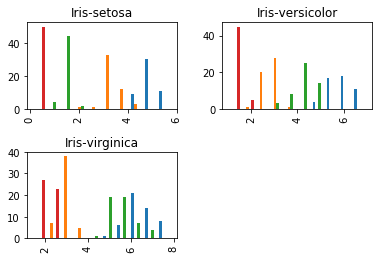

In [58]:
#sns.distplot(df['sepal_length'])
df.hist(by = 'class')

In [0]:
#Drop Id variable from data

### Question 12 
Find Correlation among all variables and give your insights 

In [0]:
#Please note, it's Require to remove correlated features because they are voted twice in the model and 
## it can lead to over inflating importance.We will ignore it here

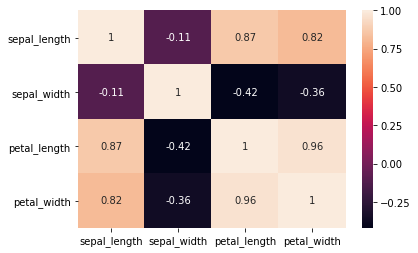

In [59]:
corr = df.corr()
sns.heatmap(corr, annot=True)

In [ ]:
# Sepal Length and Petal Lenght is very much correlated with 0.87 
# Sepal Length and Petal width is very much correlated with 0.82

### Split data in Training and test set in 80:20.

In [ ]:
Sepal elnth and petal Lenght are sr
# Cant understand above comment , assuming to choose Sepal length and Petal length as the varialbel for split, it was in the question set

In [60]:
df2 = df.drop(labels= "sepal_width" , axis = 1)
df3 = df2.drop(labels= "petal_width" , axis = 1)
X = df3.drop(labels= "class", axis = 1)
y = df3[['class']]
df5 = df3

In [61]:
from sklearn.preprocessing import LabelEncoder

lb_make = LabelEncoder()
df5['Class_code'] = lb_make.fit_transform(df5['class'])

df5.head() #Results in appending a new column to df

,sepal_length,petal_length,class,Class_code
0,5.1,1.4,Iris-setosa,0
1,4.9,1.4,Iris-setosa,0
2,4.7,1.3,Iris-setosa,0
3,4.6,1.5,Iris-setosa,0
4,5.0,1.4,Iris-setosa,0


In [62]:
df5.head(100)

,sepal_length,petal_length,class,Class_code
0,5.1,1.4,Iris-setosa,0
1,4.9,1.4,Iris-setosa,0
2,4.7,1.3,Iris-setosa,0
3,4.6,1.5,Iris-setosa,0
4,5.0,1.4,Iris-setosa,0
5,5.4,1.7,Iris-setosa,0
6,4.6,1.4,Iris-setosa,0
7,5.0,1.5,Iris-setosa,0
8,4.4,1.4,Iris-setosa,0
9,4.9,1.5,Iris-setosa,0


In [63]:
df4 = df5.drop(labels= "class" , axis = 1)

In [64]:
df4

,sepal_length,petal_length,Class_code
0,5.1,1.4,0
1,4.9,1.4,0
2,4.7,1.3,0
3,4.6,1.5,0
4,5.0,1.4,0
5,5.4,1.7,0
6,4.6,1.4,0
7,5.0,1.5,0
8,4.4,1.4,0
9,4.9,1.5,0


In [65]:
X = df4.drop(labels= "Class_code", axis = 1)
y = df4[['Class_code']]

In [66]:
y.head()

,Class_code
0,0
1,0
2,0
3,0
4,0


In [67]:
test_size = 0.20 # taking 80:20 training and test set
seed = 7  # Random numbmer seeding for reapeatability of the code
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=seed)

In [68]:
y_train

,Class_code
126,2
79,1
22,0
139,2
74,1
45,0
36,0
5,0
17,0
102,2


### Question 13 
Do Feature Scaling 

In [0]:
# Use StandardScaler or similar methods

In [69]:
from sklearn.preprocessing import StandardScaler 
scaler = StandardScaler() 
scaler.fit(X) 

StandardScaler(copy=True, with_mean=True, with_std=True)

In [70]:
X.head()

,sepal_length,petal_length
0,5.1,1.4
1,4.9,1.4
2,4.7,1.3
3,4.6,1.5
4,5.0,1.4


### Question 14 
Train and Fit NaiveBayes Model

In [0]:
#Fit the model

In [71]:
from sklearn.naive_bayes import GaussianNB

In [72]:
model = GaussianNB()

In [73]:
model.fit(X_train, y_train)
print(model)

GaussianNB(priors=None)


In [74]:
#Predict

In [75]:
# make predictions
predicted = model.predict(X_test)

In [76]:
predicted

array([2, 1, 0, 1, 1, 0, 2, 1, 0, 1, 2, 1, 0, 2, 0, 1, 2, 2, 0, 0, 1, 2,
       1, 1, 2, 1, 1, 1, 2, 2])

### Question 15 
Print Accuracy and Confusion Matrix and Conclude your findings

In [0]:
# show Confusion Matrix

In [77]:
metrics.confusion_matrix(predicted, y_test)

array([[ 7,  0,  0],
       [ 0, 10,  3],
       [ 0,  2,  8]])

In [78]:
model_score = model.score(X_test, y_test)
model_score

0.8333333333333334

In [79]:
y_predictProb = model.predict_proba(X_test)

In [80]:
y_predictProb

array([[1.60934173e-090, 4.18130272e-001, 5.81869728e-001],
       [1.79975144e-062, 9.77261786e-001, 2.27382142e-002],
       [9.99999999e-001, 7.69699232e-010, 4.73153809e-016],
       [6.34106835e-063, 9.68260075e-001, 3.17399250e-002],
       [1.21374555e-061, 9.88662674e-001, 1.13373264e-002],
       [1.00000000e+000, 2.53404720e-010, 9.10690832e-017],
       [1.83907867e-085, 1.53122429e-001, 8.46877571e-001],
       [2.85336088e-051, 9.92222476e-001, 7.77752360e-003],
       [9.99999986e-001, 1.42443501e-008, 1.06530206e-014],
       [1.83987285e-065, 8.46223943e-001, 1.53776057e-001],
       [3.84533852e-089, 1.55636288e-001, 8.44363712e-001],
       [4.82009742e-064, 9.32761778e-001, 6.72382224e-002],
       [9.99999988e-001, 1.23038602e-008, 1.31617128e-014],
       [4.60269928e-153, 4.90832023e-005, 9.99950917e-001],
       [9.99999996e-001, 3.85654234e-009, 3.56693295e-015],
       [1.65915496e-076, 7.86854240e-001, 2.13145760e-001],
       [5.69078190e-132, 1.55210734e-003

In [81]:
y_test

,Class_code
149,2
84,1
40,0
66,1
106,2
41,0
52,1
94,1
11,0
51,1


In [82]:
y_predictProb

array([[1.60934173e-090, 4.18130272e-001, 5.81869728e-001],
       [1.79975144e-062, 9.77261786e-001, 2.27382142e-002],
       [9.99999999e-001, 7.69699232e-010, 4.73153809e-016],
       [6.34106835e-063, 9.68260075e-001, 3.17399250e-002],
       [1.21374555e-061, 9.88662674e-001, 1.13373264e-002],
       [1.00000000e+000, 2.53404720e-010, 9.10690832e-017],
       [1.83907867e-085, 1.53122429e-001, 8.46877571e-001],
       [2.85336088e-051, 9.92222476e-001, 7.77752360e-003],
       [9.99999986e-001, 1.42443501e-008, 1.06530206e-014],
       [1.83987285e-065, 8.46223943e-001, 1.53776057e-001],
       [3.84533852e-089, 1.55636288e-001, 8.44363712e-001],
       [4.82009742e-064, 9.32761778e-001, 6.72382224e-002],
       [9.99999988e-001, 1.23038602e-008, 1.31617128e-014],
       [4.60269928e-153, 4.90832023e-005, 9.99950917e-001],
       [9.99999996e-001, 3.85654234e-009, 3.56693295e-015],
       [1.65915496e-076, 7.86854240e-001, 2.13145760e-001],
       [5.69078190e-132, 1.55210734e-003

In [84]:
fpr,tpr,thresholds = roc_curve(y_test, y_predictProb[::,1])

ValueError: multiclass format is not supported

In [85]:
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import LabelBinarizer
def multiclass_roc_auc_score(truth, pred, average="macro"):

    lb = LabelBinarizer()
    lb.fit(truth)

    truth = lb.transform(truth)
    pred = lb.transform(pred)

    return roc_auc_score(truth, pred, average=average)


In [292]:
#cols_to_transform = [ 'a', 'list', 'of', 'categorical', 'column', 'names' ]
#df_with_dummies = pd.get_dummies( columns = cols_to_transform,drop_first= True )

In [0]:
# show accuracy

In [271]:
preds = np.where(model.predict_proba(X_test)[:,1] > THRESHOLD, 1, 0)

In [272]:
accuracy_score(y_test, preds)

0.0

In [265]:
#THRESHOLD = optimalTh
optimalF1 = 0
optimalTh = 0

In [86]:
for th in thresholds:
    preds = np.where(model.predict_proba(X_test)[:,1] > th, 1, 0)
    f1Score = f1_score(y_test, preds)
    if(optimalF1 < f1Score):
        optimalF1 = f1Score
        optimalTh = th

NameError: name 'thresholds' is not defined

In [0]:
#Show precision and Recall metrics

# For Practice  - Optional

All the questions from 16 to 20 are for practice.

# Using SVM with Diebetes Dataset

In [0]:
#Import library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# Question 16 
Read the input file 'Diabetes.csv' using Pandas and check it's column names.

Check dimension of dataset.

Check distribution of dependent variable, Outcome and plot it.


In [0]:
# Eye ball the imported dataset

### Out of  768 data points, 500 are labeled as 0 and 268 as 1.
### Outcome 0 means No diabetes, outcome 1 means diabetes

In [0]:
# Check data types and info of dataset

# Question 17 
Check data distribution using summary statistics and provide your findings.

Do correlation analysis and bivariate viualization with Insights


# Question 18 
Do train and test split. 
Optionally - You can do with stratify sampling(optional) on Outcome variable to maintain the distribution of dependent variable

# Question 19 
Train Support Vector Machine Model(1 Marks)

In [0]:
# use from sklearn.svm import SVC

In [0]:
# your insights

# Question 20
Scale the data points using MinMaxScaler

Fit SVM Model on Scale data and give your observation

#we can try increasing either C or gamma to fit a more complex model.

# Optional Question - 
Try improving the model accuracy using C=1000 (1 Marks)

### Here, increasing C allows us to improve the model, resulting in ??? accuracy.
### Let's try to explore different Kernel and C (Bonus for practice)

In [0]:
import multiprocessing 
from sklearn.model_selection import GridSearchCV

In [0]:
 param_grid = [    {        
     'kernel': ['linear', 'rbf', 'poly', 'sigmoid'],        
     'C': [ 0.1, 0.2, 0.4, 0.5, 1.0, 1.5, 1.8, 2.0, 2.5, 3.0 ]    } ]

In [0]:
gs = GridSearchCV(estimator=SVC(), param_grid=param_grid,scoring='accuracy', cv=10, n_jobs=multiprocessing.cpu_count())

In [0]:
gs.fit(X_train_scaled, y_train) 

GridSearchCV(cv=10, error_score='raise',
       estimator=SVC(C=1.0, cache_size=200, class_weight=None, coef0=0.0,
  decision_function_shape=None, degree=3, gamma='auto', kernel='rbf',
  max_iter=-1, probability=False, random_state=None, shrinking=True,
  tol=0.001, verbose=False),
       fit_params={}, iid=True, n_jobs=4,
       param_grid=[{'kernel': ['linear', 'rbf', 'poly', 'sigmoid'], 'C': [0.1, 0.2, 0.4, 0.5, 1.0, 1.5, 1.8, 2.0, 2.5, 3.0]}],
       pre_dispatch='2*n_jobs', refit=True, return_train_score=True,
       scoring='accuracy', verbose=0)

In [0]:
gs.best_estimator_

SVC(C=2.5, cache_size=200, class_weight=None, coef0=0.0,
  decision_function_shape=None, degree=3, gamma='auto', kernel='linear',
  max_iter=-1, probability=False, random_state=None, shrinking=True,
  tol=0.001, verbose=False)

In [0]:
gs.best_score_ 

0.77777777777777779